## Load libraries and data & preprocessing

In [1]:
# load necessary libraries 
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import numpy as np
import gseapy as gp
from scipy.sparse import issparse
from scipy.stats import ttest_ind

In [2]:
# load preprocessed data 
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 190804 × 23711
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',

In [3]:
# split data in conditions 
adata_control = adata[adata.obs['condition'] == 'Control'].copy()
adata_IFN_gamma = adata[adata.obs['condition'] == 'IFNγ'].copy()
adata_co_culture = adata[adata.obs['condition'] == 'Co-culture'].copy()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


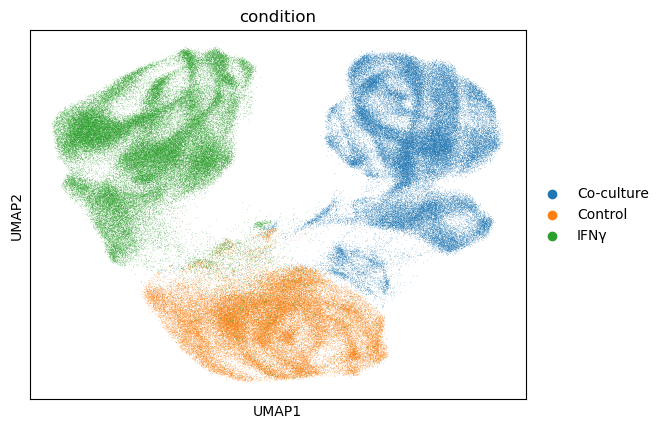

In [4]:
# UMAP over all data
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.umap(adata)
sc.pl.umap(adata, color="condition")

## Pseudo Bulk mean expression profiles and LFC

In [5]:
# define function for lfc calculation 
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = 'condition',
    pert_key: str = 'perturbation',
    control_label: str = 'control',
    min_cells: int = 15,
    pseudocount: float = 1.0,
    data_type: str = 'counts',
) -> ad.AnnData:
    """
    Computes pseudobulk log2 fold changes (LFC) per perturbation relative to controls within each condition.
    
    Parameters
    ----------
    adata : ad.AnnData
        Single-cell AnnData object (log1p normalized or raw counts in .X).
    cond_key : str
        Observation key for experimental conditions (e.g., 'Control', 'IFNγ', 'Co-culture').
    pert_key : str
        Observation key for perturbation target labels.
    control_label : str
        Label indicating unperturbed control cells within pert_key.
    min_cells : int
        Minimum number of cells required per perturbation group to keep it.
    pseudocount : float
        Small offset added to linear means to prevent zero-division in log2 ratio.
    data_type : str
        Either 'counts' or 'log1p'. Specifies the type of data in adata.X.

    Returns
    -------
    ad.AnnData
        Pseudobulk AnnData object containing Log2 Fold Changes in .X,
        retained perturbation/condition metadata in .obs, and gene annotations in .var.
    """

    # 1. Clean up labels
    obs_df = adata.obs.copy()
    obs_df[pert_key] = obs_df[pert_key].astype(str).str.strip().str.lower()
    ctrl_label_clean = str(control_label).strip().lower()

    # 2. Filter perturbations with fewer than min_dataset_cells across the entire dataset
    if min_cells > 0:
        dataset_counts = obs_df[pert_key].value_counts()
        valid_dataset_perts = dataset_counts[
            dataset_counts >= min_cells
        ].index
        cell_mask = obs_df[pert_key].isin(valid_dataset_perts).values

        adata_filtered = adata[cell_mask].copy()
        obs_df = obs_df[cell_mask].copy()
    else:
        adata_filtered = adata.copy()
    
    # 3. Extract expression matrix (linearize if log1p) or use raw counts
    if data_type == "log1p":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.expm1(X_linear.data)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.expm1(
                np.asarray(adata_filtered.X, dtype=np.float64)
            )
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    elif data_type == "counts":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.asarray(adata_filtered.X, dtype=np.float64)
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    else:
        X_linear = adata_filtered.X.copy()

    lfc_matrices = []
    obs_metadata_list = []

    # 4. Process each condition independently without per-condition min_cells filtering
    for cond_val, cond_obs in obs_df.groupby(cond_key):
        cond_indices = cond_obs.index
        cond_mask = obs_df.index.isin(cond_indices)

        # Extract linear matrix subset for this condition
        X_cond = X_linear[cond_mask, :]
        cond_perts = obs_df.loc[cond_indices, pert_key].values
        pert_counts_in_cond = cond_obs[pert_key].value_counts()

        # Locate control cells in this condition
        ctrl_mask = cond_perts == ctrl_label_clean
        if not np.any(ctrl_mask):
            print(
                f"Skipping condition '{cond_val}': No control cells"
                f" ('{ctrl_label_clean}') found."
            )
            continue

        # Compute mean linear profile for control
        if issparse(X_cond):
            ctrl_mean = np.asarray(X_cond[ctrl_mask, :].mean(axis=0)).ravel()
        else:
            ctrl_mean = X_cond[ctrl_mask, :].mean(axis=0)

        # Target all non-control perturbations present in this condition
        target_perts = [
            p for p in np.unique(cond_perts) if p != ctrl_label_clean
        ]

        cond_lfc_list = []
        retained_obs = []

        for pert in target_perts:
            p_mask = cond_perts == pert

            if issparse(X_cond):
                p_mean = np.asarray(X_cond[p_mask, :].mean(axis=0)).ravel()
            else:
                p_mean = X_cond[p_mask, :].mean(axis=0)

            # Calculate standard Log2 Fold Change
            lfc = np.log2((p_mean + pseudocount) / (ctrl_mean + pseudocount))
            cond_lfc_list.append(lfc)

            # Metadata tracking
            sample_obs_row = cond_obs[
                cond_obs[pert_key] == pert
            ].iloc[0].to_dict()
            sample_obs_row["n_cells_pseudobulk"] = pert_counts_in_cond[pert]
            retained_obs.append(sample_obs_row)

        if len(cond_lfc_list) > 0:
            lfc_matrices.append(np.vstack(cond_lfc_list))
            obs_metadata_list.extend(retained_obs)

    if not lfc_matrices:
        raise ValueError(
            "No valid perturbation groups could be computed across conditions."
        )

    # 5. Concatenate and return AnnData
    final_lfc_matrix = np.vstack(lfc_matrices)
    final_obs_df = pd.DataFrame(obs_metadata_list)
    final_obs_df.index = [
        f"{row[cond_key]}_{row[pert_key]}" for row in obs_metadata_list
    ]

    lfc_adata = ad.AnnData(
        X=final_lfc_matrix, obs=final_obs_df, var=adata_filtered.var.copy()
    )
    lfc_adata.uns["lfc_baseline_label"] = control_label
    lfc_adata.uns["pseudocount"] = pseudocount

    return lfc_adata

In [6]:
# Subset anndata to Highly Variable Genes (HVGs) 
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

In [7]:
# calculate LFC
lfc_adata_hvg = compute_pseudobulk_lfc(
    adata=adata_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=15,
    pseudocount=1.0,
    data_type='counts'
)

/tmp/ipykernel_8153/3691820588.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cond_val, cond_obs in obs_df.groupby(cond_key):


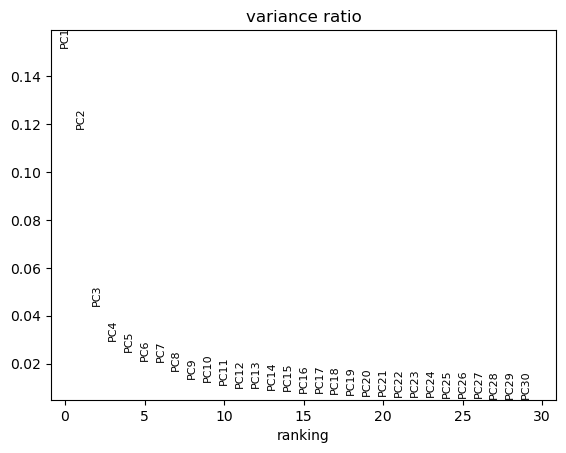

In [8]:
# PCA on LFCs and HVGs
sc.pp.pca(lfc_adata_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_hvg, n_pcs=30, log=False) # determine optimal amount of PCs with elbow plot

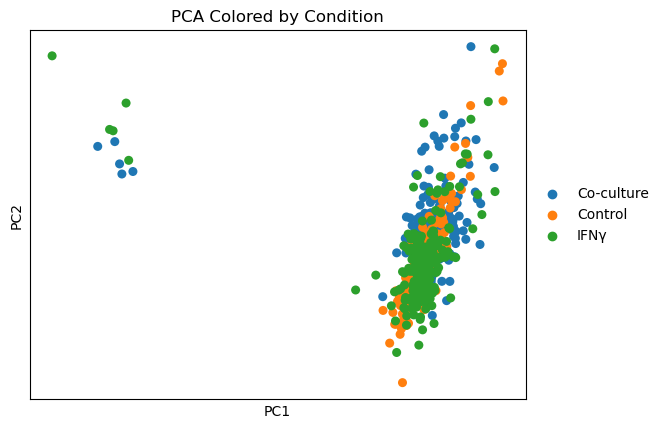

In [9]:
# reduce to 7 PCAs
sc.pp.pca(lfc_adata_hvg, n_comps=7)
sc.pl.pca(lfc_adata_hvg, color='condition', title="PCA Colored by Condition")

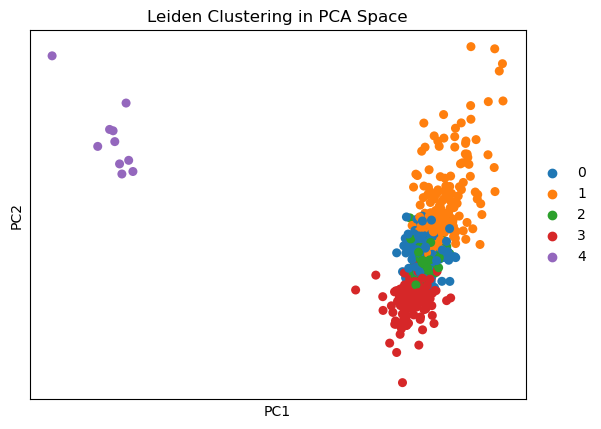

In [10]:
# Neighbors & Leiden Clustering
sc.pp.neighbors(lfc_adata_hvg, use_rep='X_pca')
sc.tl.leiden(lfc_adata_hvg, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

sc.pl.pca(lfc_adata_hvg, color='leiden', title="Leiden Clustering in PCA Space")

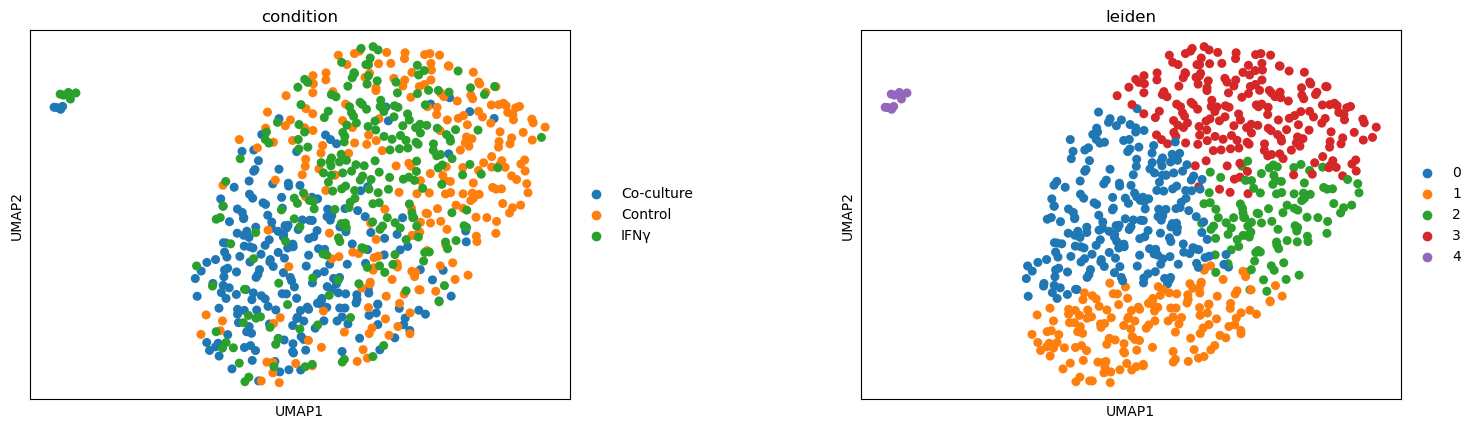

In [11]:
sc.tl.umap(lfc_adata_hvg)
sc.pl.umap(lfc_adata_hvg, color=['condition', 'leiden'], wspace=0.4)

In [12]:
# define function to get driver genes per cluster
def get_cluster_driver_genes(adata_obj, cluster_key='leiden', p_val_thresh=0.05, top_n=50):
    """
    determines driver-genes per cluster with Welch t-test based on LFCs 
    """
    drivers = {}
    df_lfc = pd.DataFrame(adata_obj.X, index=adata_obj.obs_names, columns=adata_obj.var_names)
    clusters = sorted(adata_obj.obs[cluster_key].unique(), key=lambda x: str(x))
    
    for cl in clusters:
        cl_str = str(cl)
        in_cl = df_lfc[adata_obj.obs[cluster_key] == cl]
        out_cl = df_lfc[adata_obj.obs[cluster_key] != cl]
        
        # t-Test 
        t_stat, p_vals = ttest_ind(in_cl, out_cl, axis=0, equal_var=False)
        res = pd.DataFrame({'stat': t_stat, 'pval': p_vals}, index=adata_obj.var_names).dropna()
        
        sig_res = res[res['pval'] < p_val_thresh]
        if sig_res.empty:
            sig_res = res
            
        drivers[f"{cl_str}_up"] = sig_res.sort_values('stat', ascending=False).head(top_n).index.tolist()
        drivers[f"{cl_str}_down"] = sig_res.sort_values('stat', ascending=True).head(top_n).index.tolist()
        
    return drivers

In [13]:
drivers_all_conditions = get_cluster_driver_genes(lfc_adata_hvg, cluster_key='leiden')

In [14]:
cluster_ids = sorted(lfc_adata_hvg.obs['leiden'].unique(), key=lambda x: str(x))

for cl in cluster_ids:
    cl_str = str(cl)
    up_genes = drivers_all_conditions.get(f"{cl_str}_up", [])
    down_genes = drivers_all_conditions.get(f"{cl_str}_down", [])
    
    perts = lfc_adata_hvg.obs[lfc_adata_hvg.obs['leiden'] == cl]['perturbation'].unique().tolist()
    
    print(f"\n{'='*25} Cluster {cl_str} {'='*25}")
    print(f"Enthaltene Knockouts ({len(perts)} gesamt): {perts[:8]} ...")
    print(f"\n▲ Upregulated Driver Genes ({len(up_genes)}):")
    print(", ".join(up_genes[:15]))
    print(f"\n▼ Downregulated Driver Genes ({len(down_genes)}):")
    print(", ".join(down_genes[:15]))


========================= Cluster 0 =========================
Enthaltene Knockouts (161 gesamt): ['a2m', 'aga', 'ahnak', 'apoc2', 'apod', 'apoe', 'b2m', 'c19orf48'] ...

▲ Upregulated Driver Genes (50):
IL11, HP, SERTAD1, UBE2S, PRSS3, G0S2, STC1, BTG1, NT5E, MSMP, HTRA1, IL1B, ARID5B, AL512638.2, EGR1

▼ Downregulated Driver Genes (50):
SCML4, QPRT, AKR1C3, COL3A1, S100A3, LAIR2, LIMCH1, POSTN, OGFRL1, AKR1B1, HES4, KRT8, KRT81, TNFAIP2, PI3

========================= Cluster 1 =========================
Enthaltene Knockouts (111 gesamt): ['acsl3', 'aebp1', 'ahcy', 'armc6', 'atp1b1', 'bola2', 'bola2b', 'bzw2'] ...

▲ Upregulated Driver Genes (50):
IL1B, TIMP1, TFPI2, S100A13, NEAT1, MSMP, MT1X, STC1, MT2A, CAMK2N1, ITGA2, CD63, CD55, SLC16A6, CADM1

▼ Downregulated Driver Genes (50):
CCNB1, CENPF, DLGAP5, AURKA, TPX2, HMMR, CENPE, H2AFZ, NUSAP1, CDC20, PLK1, CCNB2, BIRC5, CKS1B, CKS2

========================= Cluster 2 =========================
Enthaltene Knockouts (87 gesamt): ['act

In [15]:
# pertubations
for cluster_id in lfc_adata_hvg.obs['leiden'].unique():
    perts = lfc_adata_hvg.obs[lfc_adata_hvg.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 225) ---
['a2m', 'aga', 'ahnak', 'apoc2', 'apod', 'apoe', 'b2m', 'c19orf48', 'c6orf226', 'ccr10', 'cd151', 'cd274', 'cd44', 'cd47', 'cd63']

--- Cluster 1 (Total: 162) ---
['acsl3', 'aebp1', 'ahcy', 'armc6', 'atp1b1', 'bola2', 'bola2b', 'bzw2', 'c1qbp', 'ccnd1', 'cct3', 'cd58', 'cd59', 'cdk4', 'cdk6']

--- Cluster 2 (Total: 106) ---
['acta2', 'e2f1', 'eif3k', 'emp1', 'fbl', 'idi2-as1', 'nmrk1', 'serpine2', 'smad3', 'tm4sf1', 'tmem173', 'xage1a', 'apoc2', 'atp5md', 'bola2']

--- Cluster 3 (Total: 208) ---
['atp5md', 'ccnd2', 'cyp27a1', 'dll3', 'prelid3b', 'ruvbl2', 'tp53', 'ttll1', 'txndc17', 'uqcrh', 'wbp2', 'aebp1', 'armc6', 'atp1b1', 'c19orf48']

--- Cluster 4 (Total: 10) ---
['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1', 'ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1']


## clustering per condition

In [16]:
# LFC per condition 
log_fold_change_control_hvg = lfc_adata_hvg[lfc_adata_hvg.obs['condition'] == 'Control'].copy()
log_fold_change_IFN_gamma_hvg = lfc_adata_hvg[lfc_adata_hvg.obs['condition'] == 'IFNγ'].copy()
log_fold_change_co_culture_hvg = lfc_adata_hvg[lfc_adata_hvg.obs['condition'] == 'Co-culture'].copy()

### 1. control

In [17]:
print(log_fold_change_control_hvg)

AnnData object with n_obs × n_vars = 237 × 2000
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'n_cells_pseudobulk', 'leiden'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log

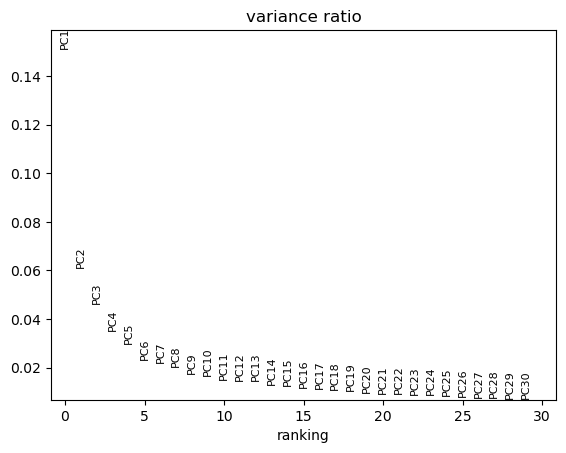

In [18]:
# PCA, find righ amount of PCs
sc.pp.pca(log_fold_change_control_hvg, n_comps=30)
sc.pl.pca_variance_ratio(log_fold_change_control_hvg, n_pcs=30, log=False)

In [19]:
# reduce to 8 PCAs and compute neighbors and leiden clustering
sc.pp.pca(log_fold_change_control_hvg, n_comps=8)
sc.pp.neighbors(log_fold_change_control_hvg, use_rep='X_pca')
sc.tl.leiden(log_fold_change_control_hvg, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

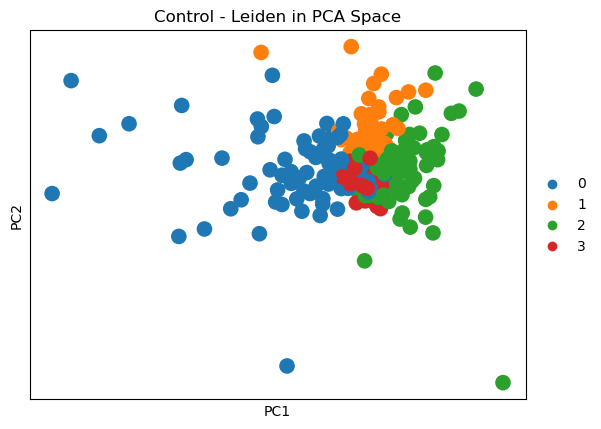

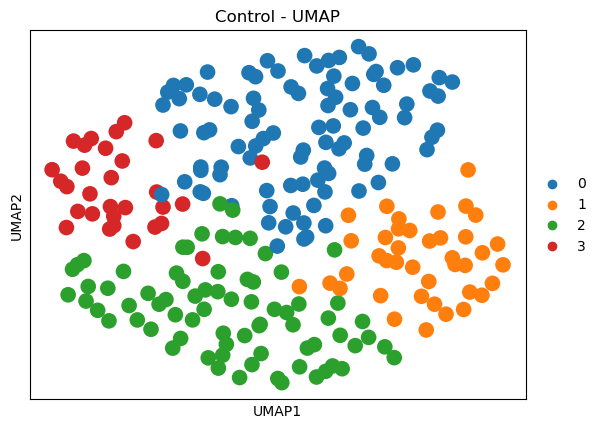

In [20]:
# visualization 
sc.pl.pca(log_fold_change_control_hvg, color='leiden', title="Control - Leiden in PCA Space")
sc.tl.umap(log_fold_change_control_hvg)
sc.pl.umap(log_fold_change_control_hvg, color='leiden', title="Control - UMAP")

In [21]:
# driver genes
drivers_control = get_cluster_driver_genes(
    log_fold_change_control_hvg, 
    cluster_key='leiden', 
    p_val_thresh=0.05, 
    top_n=50
)

cluster_ids_ctrl = sorted(log_fold_change_control_hvg.obs['leiden'].unique(), key=lambda x: str(x))


for cl in cluster_ids_ctrl:
    cl_str = str(cl)
    up_genes = drivers_control.get(f"{cl_str}_up", [])
    down_genes = drivers_control.get(f"{cl_str}_down", [])
    perts = log_fold_change_control_hvg.obs[log_fold_change_control_hvg.obs['leiden'] == cl]['perturbation'].unique().tolist()
    
    print(f"\n{'='*25} Control - Cluster {cl_str} {'='*25}")
    print(f"contained Pertubations ({len(perts)} total): {perts[:8]} ...")
    print(f"\n Upregulated Driver Genes ({len(up_genes)}):")
    print(", ".join(up_genes[:15]) if up_genes else "no significant genes")
    print(f"\n Downregulated Driver Genes ({len(down_genes)}):")
    print(", ".join(down_genes[:15]) if down_genes else "no significant genes")


========================= Control - Cluster 0 =========================
contained Pertubations (93 total): ['a2m', 'acsl3', 'aga', 'ahcy', 'apoc2', 'apod', 'b2m', 'bola2'] ...

 Upregulated Driver Genes (50):
GNLY, TIMP1, S100A13, NEAT1, STC1, MSMP, RAB27B, MT1X, PERP, SLC38A2, CD55, ADAMTS5, IL1B, TFPI2, MT2A

 Downregulated Driver Genes (50):
DLGAP5, AURKA, NUSAP1, CENPF, TPX2, CENPE, NUF2, KIF23, UBE2C, CCNB1, ASPM, MKI67, ANLN, TOP2A, CKS1B

========================= Control - Cluster 1 =========================
contained Pertubations (40 total): ['acta2', 'ahnak', 'apoe', 'armc6', 'ccnd2', 'cdkn2b', 'ctsb', 'ctso'] ...

 Upregulated Driver Genes (50):
BX470102.1, SLC35G4, ASB11, GNLY, GTSE1, NUF2, TOP2A, UBE2S, CENPF, TMEM158, UBE2C, ASPM, KIF20B, PHLDA2, PMEPA1

 Downregulated Driver Genes (50):
AC004112.1, ZNF80, KRT8, S100A2, KRT18, KRT81, QPRT, MCF2L-AS1, CHI3L1, CXXC5, AL512638.2, LEMD1, AC008264.2, AL357793.2, LINC00971

========================= Control - Cluster 2 =======

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda

In [22]:
# pertubations
for cluster_id in log_fold_change_control_hvg.obs['leiden'].unique():
    perts = log_fold_change_control_hvg.obs[log_fold_change_control_hvg.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 93) ---
['a2m', 'acsl3', 'aga', 'ahcy', 'apoc2', 'apod', 'b2m', 'bola2', 'bola2b', 'bzw2', 'c19orf48', 'ccnd1', 'ccr10', 'cct3', 'cd274']

--- Cluster 1 (Total: 40) ---
['acta2', 'ahnak', 'apoe', 'armc6', 'ccnd2', 'cdkn2b', 'ctsb', 'ctso', 'fgfr1', 'fmn1', 'fos', 'frzb', 'gaa', 'gas5', 'hla-a']

--- Cluster 2 (Total: 74) ---
['aebp1', 'atp1b1', 'c1qbp', 'cd151', 'cd58', 'cdkn1a', 'cdkn2a', 'cited1', 'ctsd', 'cxcr4', 'cyp27a1', 'ddx17', 'dll3', 'dnmt1', 'emp1']

--- Cluster 3 (Total: 30) ---
['atp5md', 'c6orf226', 'cdc123', 'cgas', 'chchd2', 'cmss1', 'eif3k', 'fbxo32', 'fstl3', 'gpatch4', 'gpnmb', 'gsn', 'hnrnpc', 'hspa1a', 'irf3']


### 2. IFN-gamma

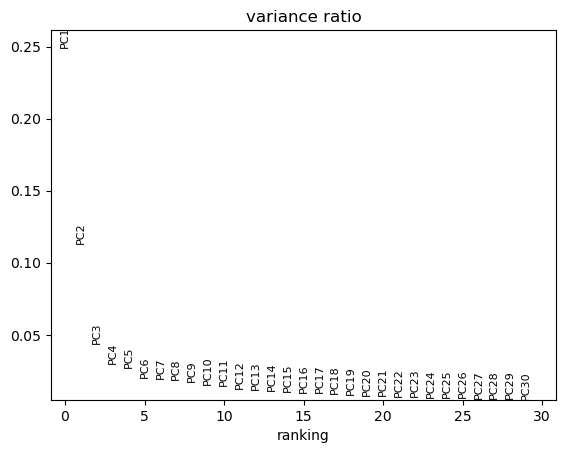

In [23]:
# PCA, find righ amount of PCs
sc.pp.pca(log_fold_change_IFN_gamma_hvg, n_comps=30)
sc.pl.pca_variance_ratio(log_fold_change_IFN_gamma_hvg, n_pcs=30, log=False)

In [24]:
# reduce to 5 PCAs and compute neighbors and leiden clustering
sc.pp.pca(log_fold_change_IFN_gamma_hvg, n_comps=5)
sc.pp.neighbors(log_fold_change_IFN_gamma_hvg, use_rep='X_pca')
sc.tl.leiden(log_fold_change_IFN_gamma_hvg, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

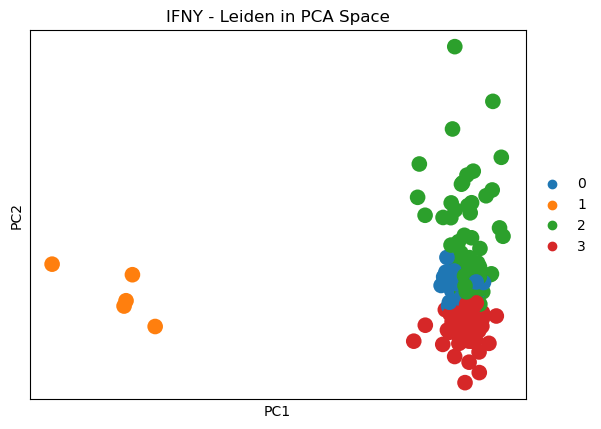

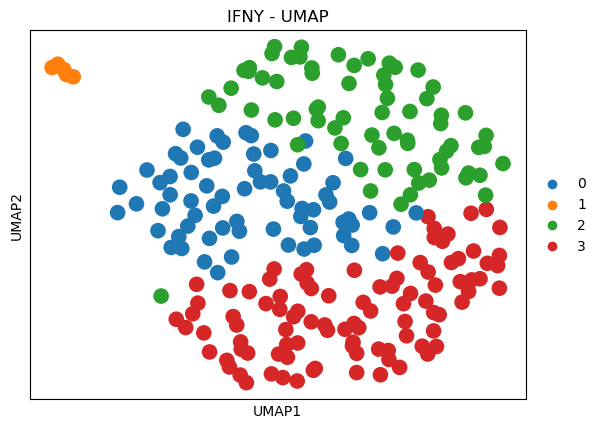

In [25]:
# visualization 
sc.pl.pca(log_fold_change_IFN_gamma_hvg, color='leiden', title="IFNY - Leiden in PCA Space")
sc.tl.umap(log_fold_change_IFN_gamma_hvg)
sc.pl.umap(log_fold_change_IFN_gamma_hvg, color='leiden', title="IFNY - UMAP")

In [33]:
# driver genes
drivers_IFNY = get_cluster_driver_genes(
    log_fold_change_IFN_gamma_hvg, 
    cluster_key='leiden', 
    p_val_thresh=0.05, 
    top_n=50
)

cluster_ids_ctrl = sorted(log_fold_change_IFN_gamma_hvg.obs['leiden'].unique(), key=lambda x: str(x))

for cl in cluster_ids_ctrl:
    cl_str = str(cl)
    up_genes = drivers_IFNY.get(f"{cl_str}_up", [])
    down_genes = drivers_IFNY.get(f"{cl_str}_down", [])
    
    perts = log_fold_change_IFN_gamma_hvg.obs[log_fold_change_IFN_gamma_hvg.obs['leiden'] == cl]['perturbation'].unique().tolist()
    
    print(f"\n{'='*25} IFNY - Cluster {cl_str} {'='*25}")
    print(f"contained Pertubations ({len(perts)} total): {perts[:8]} ...")
    print(f"\n Upregulated Driver Genes ({len(up_genes)}):")
    print(", ".join(up_genes[:15]) if up_genes else "no significant genes")
    print(f"\n Downregulated Driver Genes ({len(down_genes)}):")
    print(", ".join(down_genes[:15]) if down_genes else "no significant genes")


========================= IFNY - Cluster 0 =========================
contained Pertubations (68 total): ['a2m', 'acta2', 'ahnak', 'armc6', 'atp1b1', 'b2m', 'bola2', 'bzw2'] ...

 Upregulated Driver Genes (50):
LAIR2, ZBTB32, AL513321.2, SLC17A9, KRTAP13-4, KCNMA1, SERPINE1, NT5E, KRTAP1-3, TMEM158, CYTOR, CTSC, SFRP1, IL7R, DKK1

 Downregulated Driver Genes (50):
COL26A1, AC009097.4, LINC01297, CDR1, POSTN, CXXC5, LINC02177, QPRT, MALAT1, LINC02363, AKR1C3, HTRA3, GDF15, FBXO32, TUBA4B

========================= IFNY - Cluster 1 =========================
contained Pertubations (5 total): ['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1'] ...

 Upregulated Driver Genes (50):
PMEPA1, DCBLD2, SOX9, ARL4C, LRRC17, CAV1, EDN1, AL513321.2, SLC17A9, LAIR2, KRTAP13-4, ZBTB32, PRSS23, FRMD6, LIMCH1

 Downregulated Driver Genes (50):
ICAM1, CXCL11, SOCS1, CD7, BST2, APOBEC3G, HLA-DRA, OASL, HLA-DPA1, CXCL10, PARP14, HLA-B, IFI16, XAF1, B2M

========================= IFNY - Cluster 2 ================

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda

In [27]:
# pertubations
for cluster_id in log_fold_change_IFN_gamma_hvg.obs['leiden'].unique():
    perts = log_fold_change_IFN_gamma_hvg.obs[log_fold_change_IFN_gamma_hvg.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 68) ---
['a2m', 'acta2', 'ahnak', 'armc6', 'atp1b1', 'b2m', 'bola2', 'bzw2', 'c6orf226', 'ccnd2', 'cd151', 'cd274', 'cd63', 'cdc123', 'cdkn2a']

--- Cluster 2 (Total: 68) ---
['acsl3', 'ahcy', 'apoc2', 'apod', 'bola2b', 'c1qbp', 'ccnd1', 'cct3', 'cd44', 'cd59', 'cdk6', 'chchd2', 'cited1', 'cks1b', 'ctps1']

--- Cluster 3 (Total: 96) ---
['aebp1', 'aga', 'apoe', 'atp5md', 'c19orf48', 'ccr10', 'cd47', 'cd58', 'cdh19', 'cdk4', 'cdkn1a', 'cdkn2b', 'cgas', 'cmss1', 'ctsb']

--- Cluster 1 (Total: 5) ---
['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1']


### 3. co-culture

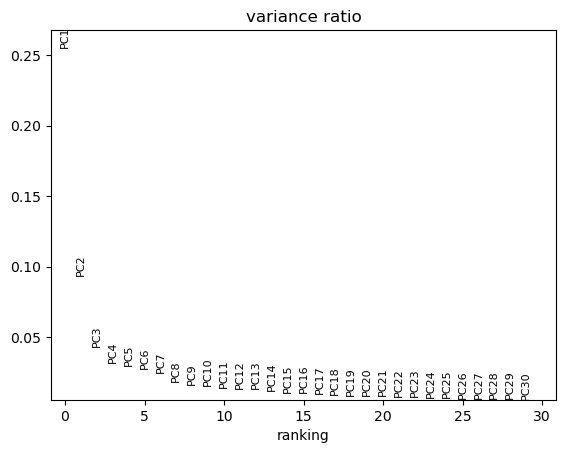

In [28]:
# PCA, find righ amount of PCs
sc.pp.pca(log_fold_change_co_culture_hvg, n_comps=30)
sc.pl.pca_variance_ratio(log_fold_change_co_culture_hvg, n_pcs=30, log=False)

In [29]:
# reduce to 5 PCAs and compute neighbors and leiden clustering
sc.pp.pca(log_fold_change_co_culture_hvg, n_comps=5)
sc.pp.neighbors(log_fold_change_co_culture_hvg, use_rep='X_pca')
sc.tl.leiden(log_fold_change_co_culture_hvg, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

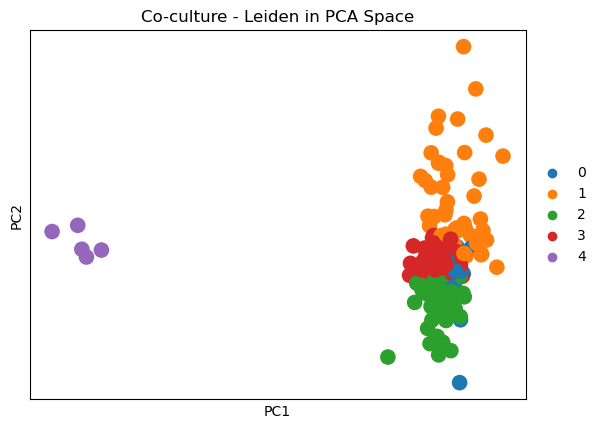

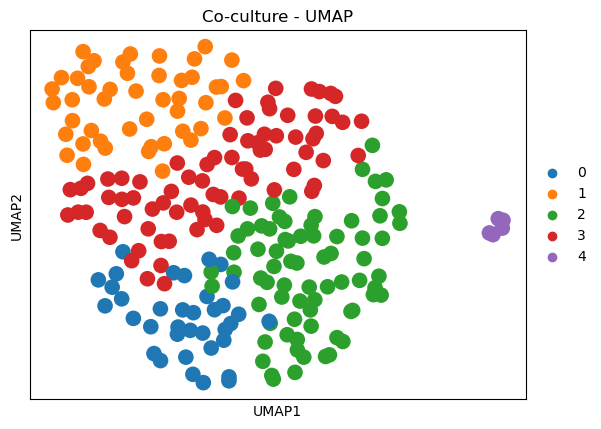

In [30]:
# visualization 
sc.pl.pca(log_fold_change_co_culture_hvg, color='leiden', title="Co-culture - Leiden in PCA Space")
sc.tl.umap(log_fold_change_co_culture_hvg)
sc.pl.umap(log_fold_change_co_culture_hvg, color='leiden', title="Co-culture - UMAP")

In [31]:
# driver genes
drivers_co_culture = get_cluster_driver_genes(
    log_fold_change_co_culture_hvg, 
    cluster_key='leiden', 
    p_val_thresh=0.05, 
    top_n=50
)

cluster_ids_ctrl = sorted(log_fold_change_co_culture_hvg.obs['leiden'].unique(), key=lambda x: str(x))

for cl in cluster_ids_ctrl:
    cl_str = str(cl)
    up_genes = drivers_co_culture.get(f"{cl_str}_up", [])
    down_genes = drivers_co_culture.get(f"{cl_str}_down", [])
    
    perts = log_fold_change_co_culture_hvg.obs[log_fold_change_co_culture_hvg.obs['leiden'] == cl]['perturbation'].unique().tolist()
    
    print(f"\n{'='*25} Co-culture - Cluster {cl_str} {'='*25}")
    print(f"contained Pertubations ({len(perts)} total): {perts[:8]} ...")
    print(f"\n Upregulated Driver Genes ({len(up_genes)}):")
    print(", ".join(up_genes[:15]) if up_genes else "no significant genes")
    print(f"\n Downregulated Driver Genes ({len(down_genes)}):")
    print(", ".join(down_genes[:15]) if down_genes else "no significant genes")


========================= Co-culture - Cluster 0 =========================
contained Pertubations (36 total): ['a2m', 'b2m', 'c19orf48', 'ccnd1', 'cd63', 'chchd2', 'cited1', 'cmss1'] ...

 Upregulated Driver Genes (50):
LINC02417, OPA1-AS1, ADAM30, AP001266.1, GIMAP8, MS4A7, CHST8, CDR1, C19orf71, AC009060.1, EDA, AP001189.4, ZNF80, SLC17A9, AC016687.3

 Downregulated Driver Genes (50):
LINC02093, DCHS2, ALOX15B, MIR122HG, OSTN, LINC00452, DCT, PPEF2, AC126696.2, SOX8, CFHR5, G2E3-AS1, TULP2, AL049835.1, LINC01749

========================= Co-culture - Cluster 1 =========================
contained Pertubations (47 total): ['acsl3', 'ahcy', 'atp1b1', 'bola2', 'bola2b', 'bzw2', 'cct3', 'cdk6'] ...

 Upregulated Driver Genes (50):
ADAM30, GIMAP8, LINC02417, EDA, AP001266.1, CDR1, SLC17A9, C19orf71, AC009060.1, AP001189.4, ZNF80, OPA1-AS1, IL1B, MS4A7, CHST8

 Downregulated Driver Genes (50):
LINC02093, AC126696.2, PPEF2, CFHR5, MIR122HG, ALOX15B, DCT, LINC00452, OSTN, SOX8, DCHS2, CDC20

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/home/ubuntu/miniconda

In [32]:
# pertubations
for cluster_id in log_fold_change_co_culture_hvg.obs['leiden'].unique():
    perts = log_fold_change_co_culture_hvg.obs[log_fold_change_co_culture_hvg.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 36) ---
['a2m', 'b2m', 'c19orf48', 'ccnd1', 'cd63', 'chchd2', 'cited1', 'cmss1', 'ctsl', 'cxcr4', 'cyp27a1', 'dag1', 'ddx17', 'e2f1', 'eef1g']

--- Cluster 1 (Total: 47) ---
['acsl3', 'ahcy', 'atp1b1', 'bola2', 'bola2b', 'bzw2', 'cct3', 'cdk6', 'ctps1', 'ctsb', 'ddx39a', 'dnmt1', 'eif4a1', 'farsa', 'fkbp4']

--- Cluster 2 (Total: 74) ---
['acta2', 'aga', 'apod', 'atp5md', 'c6orf226', 'ccnd2', 'cd151', 'cd44', 'cd47', 'cdkn2a', 'cgas', 'cst3', 'ctsa', 'ctsd', 'dll3']

--- Cluster 3 (Total: 75) ---
['aebp1', 'ahnak', 'apoc2', 'apoe', 'armc6', 'c1qbp', 'ccr10', 'cd274', 'cd58', 'cd59', 'cdc123', 'cdh19', 'cdk4', 'cdkn1a', 'cdkn2b']

--- Cluster 4 (Total: 5) ---
['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1']
